# MOBO for Rb₃BiI₆ Perovskite Synthesis Round 2

**Objectives:**
- **Coverage**: Maximize surface coverage (0-1)
- **Uniformity**: Minimize non-uniformity (lower is better)
- **Phase Purity**: Maximize phase purity (higher is better)

**Process Parameters:**
- Spin Speed [rpm]: 500-5000
- Precursor Concentration [mol/L]: 0.1-1.5
- Annealing Temperature [°C]: 100-300
- Solvent Ratio: 1-4
- Solute Ratio: 2.8-3.2

In [5]:
import numpy as np
import pandas as pd
import random
import torch
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from botorch.models import SingleTaskGP, ModelListGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.monte_carlo import qNoisyExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.utils.multi_objective.pareto import is_non_dominated

from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.priors import LogNormalPrior
from gpytorch.mlls import ExactMarginalLogLikelihood
import gpytorch

from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")

In [6]:
# Utility functions for normalization and discretization
def x_normalizer(X, var_array):
    """Normalize parameters to [0,1] range"""
    def max_min_scaler(x, x_max, x_min):
        return (x-x_min)/(x_max-x_min)
    x_norm = []
    for x in X:
        x_norm.append([max_min_scaler(x[i], max(var_array[i]), min(var_array[i])) 
                      for i in range(len(x))])
    return x_norm

def x_denormalizer(x_norm, var_array):
    """Convert normalized parameters back to original scale"""
    def max_min_rescaler(x, x_max, x_min):
        return x*(x_max-x_min)+x_min
    x_original = []
    for x in x_norm:
        x_original.append([max_min_rescaler(x[i], max(var_array[i]), min(var_array[i])) 
                          for i in range(len(x))])
    return x_original

def get_closest_array(suggested_x, var_list):
    """Snap suggested parameters to discrete grids"""
    def get_closest_value(given_value, array_list):
        return min(array_list, key=lambda x: abs(x - given_value))
    
    modified_array = []
    for x in suggested_x:
        modified_array.append([get_closest_value(x[i], var_list[i]) for i in range(len(x))])
    return np.array(modified_array)

In [7]:

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Device setup
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# Define parameter ranges
var_array = [
    np.arange(500, 5500, 500, dtype=float),      # Spin Speed [rpm]
    np.round(np.arange(0.1, 1.6, 0.1), 2),      # Concentration [mol/L] 
    np.arange(100, 310, 10, dtype=float),       # Annealing Temp [°C]
    np.arange(1, 5, 1, dtype=float),            # Solvent Ratio
    np.round(np.arange(2.8, 3.3, 0.1), 2)      # Solute Ratio
]

x_labels = ["Spin Speed [rpm]", "Precursor Concentration [mol/L]", 
           "Annealing Temperature [°C]", "Solvent Ratio", "Solute Ratio"]
y_labels = ["coverage", "uniformity", "phase_purity"]
objective_names = ['Coverage', 'Uniformity', 'Phase Purity']

Using device: cpu


In [8]:
# Load experimental data
df = pd.DataFrame([
    [0, 5000, 0.6, 290, 2, 3, 0.457, 1.910000756, 0.231655124],
    [1, 5000, 0.6, 290, 2, 3, 0.983, 1.168303624, 0.476353586],
    [2, 5000, 0.6, 290, 2, 3, 0.986, 1.17944191, 0.522201608],
    [3, 3500, 1.1, 220, 2, 3.3, 0.971, 1.037466875, 0.713780128],
    [4, 3500, 1.1, 220, 2, 3.3, 0.99, 1.183551423, 0.801536479],
    [5, 3500, 1.1, 220, 2, 3.3, 0.953, 1.164664288, 0.752608116],
    [6, 2500, 0.7, 210, 1, 3.1, 0.966, 1.052904152, 0.792829367],
    [7, 2500, 0.7, 210, 1, 3.1, 0.985, 1.15489352, 0.846302496],
    [8, 2500, 0.7, 210, 1, 3.1, 0.956, 1.238139933, 0.882449763],
    [9, 2000, 0.5, 240, 4, 3.2, 0.98, 1.031476872, 0.657161413],
    [10, 2000, 0.5, 240, 4, 3.2, 0.872, 1.480060031, 0.485102891],
    [11, 2000, 0.5, 240, 4, 3.2, 0.993, 1.098000725, 0.730408225],
    [12, 3000, 0.9, 140, 1, 3.1, 0.976, 0.891103708, 0.689083963],
    [13, 3000, 0.9, 140, 1, 3.1, 0.959, 1.130017172, 0.687624889],
    [14, 3000, 0.9, 140, 1, 3.1, 0.881, 1.225081002, 0.629659251],
    [15, 1500, 1, 160, 2, 2.8, 0.933, 0.96667918, 0.760603839],
    [16, 1500, 1, 160, 2, 2.8, 0.982, 1.162898835, 0.727085314],
    [17, 1500, 1, 160, 2, 2.8, 0.975, 1.155157279, 0.785477686],
    [18, 3500, 0.3, 260, 3, 2.9, 0.939, 1.025664349, 0.472098548],
    [19, 3500, 0.3, 260, 3, 2.9, 0.97, 1.184886737, 0.554688171],
    [20, 3500, 0.3, 260, 3, 2.9, 0.972, 1.1270837, 0.730100781],
    [21, 2000, 0.4, 110, 2, 3.2, 0.966, 1.136370969, 0.777128114],
    [22, 2000, 0.4, 110, 2, 3.2, 0.988, 1.163401747, 0.807794052],
    [23, 2000, 0.4, 110, 2, 3.2, 0.971, 1.31795935, 0.852633948],
    [24, 1000, 1.2, 270, 3, 3.2, 0, 3, 0],
    [25, 1000, 1.2, 270, 3, 3.2, 0, 3, 0],
    [26, 1000, 1.2, 270, 3, 3.2, 0, 3, 0],
    [27, 4000, 1.3, 170, 3, 2.9, 0.973, 1.060466397, 0.45245535],
    [28, 4000, 1.3, 170, 3, 2.9, 0.98, 1.290988776, 0.5329505],
    [29, 4000, 1.3, 170, 3, 2.9, 0.962, 1.142054872, 0.580075932],
    [30, 4500, 1.4, 120, 4, 3, 0.976, 0.958154885, 0.700926029],
    [31, 4500, 1.4, 120, 4, 3, 0.989, 1.049059025, 0.61274826],
    [32, 4500, 1.4, 120, 4, 3, 0.959, 1.122968431, 0.699343607],
    [33, 500, 0.2, 190, 3, 2.9, 0.963, 1.424032262, 0.762198275],
    [34, 500, 0.2, 190, 3, 2.9, 0.923, 1.498621407, 0.777255845],
    [35, 500, 0.2, 190, 3, 2.9, 0.995, 1.370632824, 0.759614445],
    [36, 3000, 0.1, 210, 3, 3.2, 0.941101507, 1.166513892, 0.76813087],
    [37, 3000, 0.1, 210, 3, 3.2, 0.952577598, 0.853156903, 0.910036311],
    [38, 3000, 0.1, 210, 3, 3.2, 0.968167361, 0.836757933, 0.956292966],
    [39, 2000, 0.1, 180, 2, 2.8, 0.936869376, 1.08757489, 0.90974823],
    [40, 2000, 0.1, 180, 2, 2.8, 0.958812416, 1.032544072, 0.945593559],
    [41, 2000, 0.1, 180, 2, 2.8, 0.964394268, 1.002913946, 0.955976908],
    [42, 4000, 0.1, 220, 4, 3.2, 0.731938844, 1.244904335, 0.517350641],
    [43, 4000, 0.1, 220, 4, 3.2, 0.978802643, 1.003275369, 0.65684391],
    [44, 4000, 0.1, 220, 4, 3.2, 0.924686081, 1.017394883, 0.629135001],
    [45, 2000, 0.5, 200, 2, 2.8, 0.946727224, 0.746156335, 0.858544667],
    [46, 2000, 0.5, 200, 2, 2.8, 0.996689304, 0.683689559, 0.890973836],
    [47, 2000, 0.5, 200, 2, 2.8, 0.95297714, 0.765508495, 0.848244644],
    [48, 3000, 0.8, 210, 2, 2.8, 0.965679825, 0.834537996, 0.33119379],
    [49, 3000, 0.8, 210, 2, 2.8, 0.972649287, 0.794870939, 0.309913526],
    [50, 3000, 0.8, 210, 2, 2.8, 0.987007168, 0.891272795, 0.397443425],
    [51, 2500, 0.1, 210, 1, 3, 0.833173433, 1.352976876, 0.749883909],
    [52, 2500, 0.1, 210, 1, 3, 0.938380968, 1.166346717, 0.846554546],
    [53, 2500, 0.1, 210, 1, 3, 0.972342914, 0.876690503, 0.923684237],
], columns=["#sample"] + x_labels + y_labels)

print(f"✓ Loaded {len(df)} experimental data points")
print(f"Parameters: {x_labels}")
print(f"Objectives: {y_labels}")
display(df.head())

✓ Loaded 54 experimental data points
Parameters: ['Spin Speed [rpm]', 'Precursor Concentration [mol/L]', 'Annealing Temperature [°C]', 'Solvent Ratio', 'Solute Ratio']
Objectives: ['coverage', 'uniformity', 'phase_purity']


,#sample,Spin Speed [rpm],Precursor Concentration [mol/L],Annealing Temperature [°C],Solvent Ratio,Solute Ratio,coverage,uniformity,phase_purity
0,0,5000,0.6,290,2,3.0,0.457,1.910001,0.231655
1,1,5000,0.6,290,2,3.0,0.983,1.168304,0.476354
2,2,5000,0.6,290,2,3.0,0.986,1.179442,0.522202
3,3,3500,1.1,220,2,3.3,0.971,1.037467,0.713780
4,4,3500,1.1,220,2,3.3,0.990,1.183551,0.801536


In [9]:
# Data preprocessing
print("=== Data Preprocessing ===")

# Prepare training data
X_train = df[x_labels].values
Y_train = df[y_labels].values

print(f"Training data: X shape {X_train.shape}, Y shape {Y_train.shape}")

# Handle objective directions: convert uniformity (minimize) to maximize by negation
Y_processed = Y_train.copy()
Y_processed[:, 1] = -Y_processed[:, 1]  # Negate uniformity for maximization

# Normalize inputs to [0, 1] and convert to tensors
X_normalized = x_normalizer(X_train, var_array)
X_tensor = torch.FloatTensor(X_normalized).to(device)
Y_tensor = torch.FloatTensor(Y_processed).to(device)

=== Data Preprocessing ===
Training data: X shape (54, 5), Y shape (54, 3)


In [10]:
# Gaussian Process model fitting
print("=== Fitting Gaussian Process Models ===")

def fit_gp_models(X, Y, kernel_fn=None, noise_priors=None):
    """
    Fits GP models following MOBO-Kit implementation.
    One GP per objective with Matern kernel and custom noise priors.
    """
    # Input validation
    X_min, X_max = X.min(), X.max()
    if X_min < 0.0 or X_max > 1.0:
        warnings.warn(f"X not normalized to [0,1]: [{X_min:.4f}, {X_max:.4f}]", UserWarning)
    
    models = []
    D, M = X.shape[1], Y.shape[1]
    
    # Handle kernel function
    if kernel_fn is None:
        kernel_fns = [lambda d: MaternKernel(nu=2.5, ard_num_dims=d)] * M
    elif callable(kernel_fn):
        kernel_fns = [kernel_fn] * M
    else:
        raise TypeError("kernel_fn must be callable or None")
    
    # Handle noise priors
    if noise_priors is None:
        noise_priors_list = [None] * M
    elif isinstance(noise_priors, list):
        if len(noise_priors) != M:
            raise ValueError(f"noise_priors length ({len(noise_priors)}) must match M={M}")
        noise_priors_list = noise_priors
    else:
        noise_priors_list = [noise_priors] * M
    
    # Move priors to device
    for k in range(M):
        p = noise_priors_list[k]
        if p is not None and hasattr(p, "to"):
            noise_priors_list[k] = p.to(X.device)
    
    # Fit one GP per objective
    for j in range(M):
        base_kernel = kernel_fns[j](D)
        covar_module = ScaleKernel(base_kernel)
        
        pj = noise_priors_list[j]
        likelihood = gpytorch.likelihoods.GaussianLikelihood(
            noise_prior=pj,
            noise_constraint=gpytorch.constraints.GreaterThan(1e-3),
        )
        
        gp = SingleTaskGP(
            X, Y[:, j:j+1],
            covar_module=covar_module, 
            likelihood=likelihood,
            outcome_transform=Standardize(m=1)
        )
        
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        
        # Robust fitting with retry
        try:
            fit_gpytorch_mll(mll)
        except Exception as e:
            print(f"[GP {j}] First fit failed ({e}), retrying...")
            try:
                gp.likelihood.noise_covar.register_constraint(
                    "raw_noise", gpytorch.constraints.GreaterThan(1e-2)
                )
                with torch.no_grad():
                    gp.likelihood.noise = torch.as_tensor(1e-2, device=X.device, dtype=X.dtype)
                fit_gpytorch_mll(mll)
            except Exception as e2:
                print(f"[GP {j}] Retry failed ({e2}), using initial hyperparameters")
        
        models.append(gp)
    
    return ModelListGP(*models)

# Define noise priors and kernel function
noise_priors = [
    LogNormalPrior(-3.0, 0.5),  # Coverage
    LogNormalPrior(-3.0, 0.5),  # Uniformity (neg)
    LogNormalPrior(-3.0, 0.5),  # Phase Purity
]


kernel_fn = lambda d: MaternKernel(nu=2.5, ard_num_dims=d)

# Fit the model
model = fit_gp_models(X_tensor, Y_tensor, kernel_fn=kernel_fn, noise_priors=noise_priors)
print("✓ GP models fitted successfully")

=== Fitting Gaussian Process Models ===
✓ GP models fitted successfully


=== Model Validation & Diagnostics ===


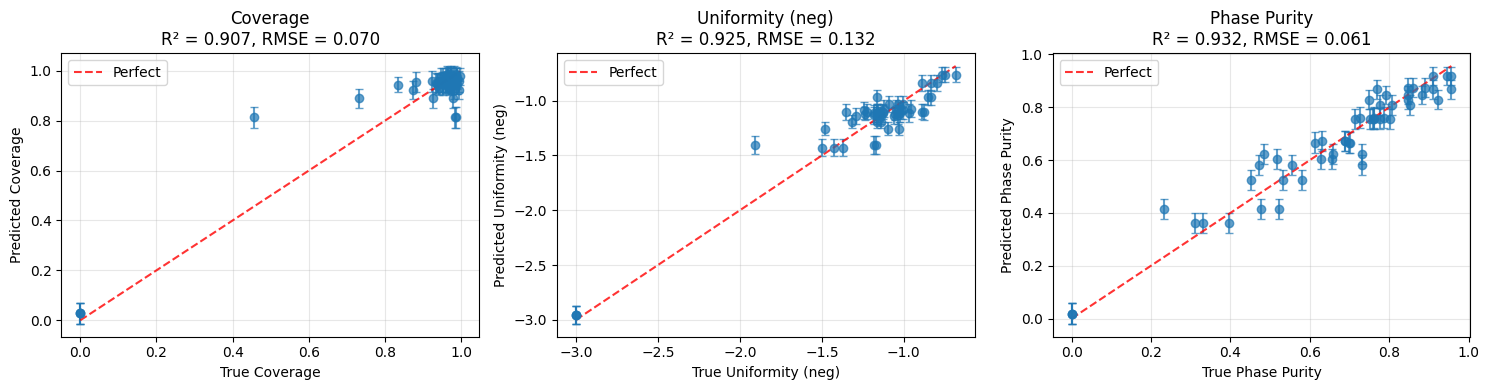


Model Performance:
Coverage: R² = 0.9074, RMSE = 0.0703
Uniformity (neg): R² = 0.9247, RMSE = 0.1319
Phase Purity: R² = 0.9317, RMSE = 0.0609

✓ Model validation complete


In [11]:
# Model validation and diagnostics
print("=== Model Validation & Diagnostics ===")

def posterior_report(model, X):
    """Get posterior predictions with uncertainty quantification"""
    with torch.no_grad():
        posterior = model.posterior(X)
        pred_mean_t = posterior.mean
        pred_std_t = torch.sqrt(posterior.variance)
    
    pred_mean = pred_mean_t.cpu().numpy()
    pred_std = pred_std_t.cpu().numpy()
    return pred_mean, pred_std

def compute_metrics(true_Y, pred_mean, objective_names):
    """Calculate R² and RMSE for each objective"""
    metrics = []
    for j, obj_name in enumerate(objective_names):
        true_vals = true_Y[:, j]
        pred_vals = pred_mean[:, j]
        
        r2 = r2_score(true_vals, pred_vals)
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        
        metrics.append({
            'objective': obj_name,
            'r2': round(r2, 4),
            'rmse': round(rmse, 4)
        })
    
    return pd.DataFrame(metrics)

def plot_parity(Y_true, Y_pred, Y_std, objective_names):
    """Create parity plots for model validation"""
    n_obj = len(objective_names)
    fig, axes = plt.subplots(1, n_obj, figsize=(5*n_obj, 4))
    if n_obj == 1:
        axes = [axes]
    
    for j, (ax, obj_name) in enumerate(zip(axes, objective_names)):
        true_vals = Y_true[:, j]
        pred_vals = Y_pred[:, j]
        
        # Calculate metrics
        r2 = r2_score(true_vals, pred_vals)
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        
        # Plot with error bars
        ax.errorbar(true_vals, pred_vals, yerr=Y_std[:, j], fmt='o', alpha=0.7, capsize=3)
        
        # Perfect prediction line
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect')
        
        ax.set_xlabel(f'True {obj_name}')
        ax.set_ylabel(f'Predicted {obj_name}')
        ax.set_title(f'{obj_name}\nR² = {r2:.3f}, RMSE = {rmse:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Get predictions and calculate metrics
pred_mean, pred_std = posterior_report(model, X_tensor)
Y_np = Y_tensor.cpu().numpy()

# Create parity plots
fig_parity = plot_parity(Y_np, pred_mean, pred_std, ['Coverage', 'Uniformity (neg)', 'Phase Purity'])
plt.savefig('model_parity_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display metrics
metrics_df = compute_metrics(Y_np, pred_mean, ['Coverage', 'Uniformity (neg)', 'Phase Purity'])
print("\nModel Performance:")
for _, row in metrics_df.iterrows():
    print(f"{row['objective']}: R² = {row['r2']:.4f}, RMSE = {row['rmse']:.4f}")

print("\n✓ Model validation complete")

In [12]:
# Pareto front analysis
print("=== Pareto Front Analysis ===")

def compute_ref_pareto_hv(Y_t, ref_point=None):
    """Compute Pareto front and hypervolume"""
    pareto_mask = is_non_dominated(Y_t)
    pareto_Y_t = Y_t[pareto_mask]
    
    if ref_point is None:
        ref_point = Y_t.min(dim=0)[0] - 0.01
    
    bd = FastNondominatedPartitioning(ref_point=ref_point, Y=pareto_Y_t)
    hv_val = bd.compute_hypervolume().item()
    
    return ref_point, pareto_Y_t, hv_val

# Find Pareto front
ref_point_t, pareto_Y_t, hv_val = compute_ref_pareto_hv(Y_tensor)
pareto_mask = is_non_dominated(Y_tensor)
pareto_X = X_tensor[pareto_mask]

print(f"Pareto front: {pareto_Y_t.shape[0]} out of {Y_tensor.shape[0]} points")
print(f"Current hypervolume: {hv_val:.4f}")
print("\nPareto front points (Coverage, -Uniformity, Phase Purity):")
print(pareto_Y_t.cpu().numpy())

print("✓ Pareto analysis complete")

=== Pareto Front Analysis ===
Pareto front: 3 out of 54 points
Current hypervolume: 2.2491

Pareto front points (Coverage, -Uniformity, Phase Purity):
[[ 0.96816736 -0.83675796  0.956293  ]
 [ 0.9966893  -0.68368953  0.8909738 ]
 [ 0.9723429  -0.8766905   0.92368424]]
✓ Pareto analysis complete


In [17]:
# Acquisition function and batch proposal
print("=== Proposing New Experiments ===")

def propose_batch(X_t, Y_t, model, ref_point_t, batch_size=5, 
                  num_restarts=10, raw_samples=256, verbose=True):
    """Propose new experiments using qNEHVI acquisition function"""
    if verbose:
        print(f"Proposing {batch_size} candidates...")
        print(f"Optimization: {num_restarts} restarts, {raw_samples} raw samples")
    
    # Setup acquisition function
    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([32]))
    acq_func = qNoisyExpectedHypervolumeImprovement(
        model=model,
        ref_point=ref_point_t,
        X_baseline=X_t,
        sampler=sampler,
    )
    
    # Define bounds
    bounds = torch.stack([
        torch.zeros(X_t.shape[1]),
        torch.ones(X_t.shape[1])
    ]).to(X_t.device)
    
    try:
        candidates, acq_values = optimize_acqf(
            acq_function=acq_func,
            bounds=bounds,
            q=batch_size,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )
        
        # Convert to physical units
        candidates_np = candidates.detach().cpu().numpy()
        candidates_denorm = x_denormalizer(candidates_np, var_array)
        candidates_discrete = get_closest_array(candidates_denorm, var_array)
        
        result = {
            'X_phys': candidates_discrete,
            'X_norm': candidates_np,
            'acq_val': acq_values.detach().cpu().numpy(),
            'success': True
        }
        
        if verbose:
            print(f"✓ Successfully proposed {len(candidates_discrete)} candidates")
        
        return result
        
    except Exception as e:
        if verbose:
            print(f"✗ Optimization failed: {e}")
        return {'X_phys': None, 'X_norm': None, 'acq_val': None, 'success': False}

# Propose new experiments
batch_size = 6
out = propose_batch(
    X_t=X_tensor, 
    Y_t=Y_tensor,
    model=model, 
    ref_point_t=ref_point_t, 
    batch_size=batch_size,
    num_restarts=10,
    raw_samples=256,
    verbose=True
)

if out['success']:
    # Create DataFrame for proposed experiments
    proposed_experiments = pd.DataFrame(out['X_phys'], columns=x_labels)
    print("\nProposed next experiments:")
    display(proposed_experiments)
    
    # Predict outcomes
    candidates_tensor = torch.FloatTensor(out['X_norm']).to(device)
    with torch.no_grad():
        posterior = model.posterior(candidates_tensor)
        pred_mean = posterior.mean.cpu().numpy()
        pred_std = posterior.variance.sqrt().cpu().numpy()
    
    # Convert back to original objective space
    pred_display = pred_mean.copy()
    pred_display[:, 1] = -pred_display[:, 1]  # Convert uniformity back
    
    print("\nPredicted outcomes [coverage, uniformity, phase_purity]:")
    for i in range(len(pred_display)):
        print(f"Exp {i+1}: [{pred_display[i,0]:.3f}, {pred_display[i,1]:.3f}, {pred_display[i,2]:.3f}] "
              f"± [{pred_std[i,0]:.3f}, {pred_std[i,1]:.3f}, {pred_std[i,2]:.3f}]")
    
    print("\n✓ Batch proposal complete")
else:
    print("✗ Failed to propose new experiments")

=== Proposing New Experiments ===
Proposing 6 candidates...
Optimization: 10 restarts, 256 raw samples
✓ Successfully proposed 6 candidates

Proposed next experiments:


,Spin Speed [rpm],Precursor Concentration [mol/L],Annealing Temperature [°C],Solvent Ratio,Solute Ratio
0,2000.0,0.3,150.0,1.0,2.9
1,3000.0,0.1,260.0,3.0,3.2
2,2000.0,0.6,150.0,3.0,2.8
3,5000.0,1.0,200.0,4.0,3.2
4,500.0,0.6,110.0,1.0,2.8
5,2000.0,1.4,100.0,3.0,2.8



Predicted outcomes [coverage, uniformity, phase_purity]:
Exp 1: [0.972, 0.989, 0.926] ± [0.060, 0.092, 0.118]
Exp 2: [0.934, 0.973, 0.818] ± [0.085, 0.074, 0.142]
Exp 3: [0.985, 0.740, 0.905] ± [0.058, 0.073, 0.103]
Exp 4: [1.005, 1.034, 0.548] ± [0.130, 0.251, 0.203]
Exp 5: [1.014, 1.303, 0.727] ± [0.147, 0.217, 0.197]
Exp 6: [0.952, 1.340, 0.826] ± [0.184, 0.235, 0.173]

✓ Batch proposal complete


=== 3D Pareto Front Visualization ===


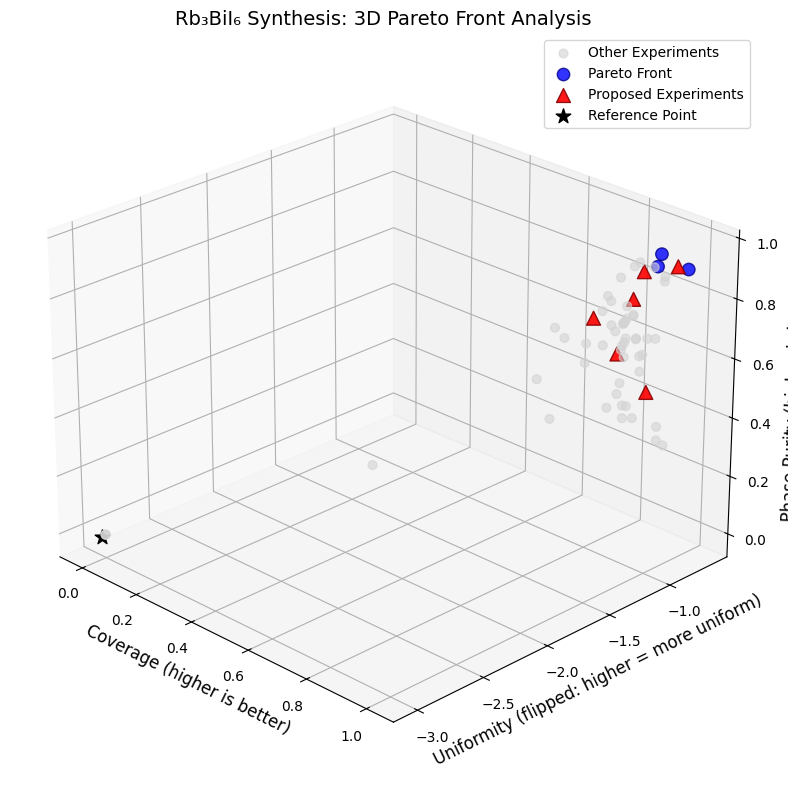


3D Pareto Analysis Summary:
• Total experiments: 54
• Pareto-optimal points: 3
• Proposed new experiments: 6
• Current hypervolume: 2.2491

✓ 3D visualization complete


In [18]:
# 3D Pareto front visualization
print("=== 3D Pareto Front Visualization ===")

# Settings for visualization (all objectives maximized after preprocessing)
maximize = [True, True, True]  # [Coverage, -Uniformity, Phase Purity]

def _flip_for_plot(Y_t, maximize_flags):
    """Prepare data for plotting with consistent 'higher is better' axes"""
    Y_np = Y_t.detach().cpu().numpy().copy()
    for j, is_max in enumerate(maximize_flags):
        if not is_max:
            Y_np[:, j] = -Y_np[:, j]
    return Y_np

# Prepare data for visualization
all_Y_np_plot = _flip_for_plot(Y_tensor, maximize)
pareto_Y_np_plot = _flip_for_plot(pareto_Y_t, maximize)
ref_point_np_plot = _flip_for_plot(ref_point_t.view(1, -1), maximize)

if out['success']:
    Y_next_t = torch.FloatTensor(pred_mean).to(device)
    next_Y_np_plot = _flip_for_plot(Y_next_t, maximize)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot all points
non_pareto_mask = ~is_non_dominated(Y_tensor).cpu().numpy()
if non_pareto_mask.any():
    ax.scatter(
        all_Y_np_plot[non_pareto_mask, 0], 
        all_Y_np_plot[non_pareto_mask, 1], 
        all_Y_np_plot[non_pareto_mask, 2],
        c='lightgray', s=40, alpha=0.6, label='Other Experiments'
    )

# Pareto front
ax.scatter(
    pareto_Y_np_plot[:, 0], pareto_Y_np_plot[:, 1], pareto_Y_np_plot[:, 2],
    c='blue', s=80, label='Pareto Front', alpha=0.8, edgecolors='darkblue'
)

# Proposed experiments
if out['success']:
    ax.scatter(
        next_Y_np_plot[:, 0], next_Y_np_plot[:, 1], next_Y_np_plot[:, 2],
        c='red', s=100, marker='^', label='Proposed Experiments', 
        alpha=0.9, edgecolors='darkred'
    )

# Reference point
ax.scatter(
    ref_point_np_plot[0, 0], ref_point_np_plot[0, 1], ref_point_np_plot[0, 2],
    c='black', s=120, marker='*', label='Reference Point'
)

# Labels and formatting
ax.set_xlabel('Coverage (higher is better)', fontsize=12)
ax.set_ylabel('Uniformity (flipped: higher = more uniform)', fontsize=12)
ax.set_zlabel('Phase Purity (higher is better)', fontsize=12)
ax.set_title('Rb₃BiI₆ Synthesis: 3D Pareto Front Analysis', fontsize=14)
ax.legend(loc='best')
ax.view_init(elev=25, azim=-45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_3d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n3D Pareto Analysis Summary:")
print(f"• Total experiments: {len(all_Y_np_plot)}")
print(f"• Pareto-optimal points: {len(pareto_Y_np_plot)}")
print(f"• Proposed new experiments: {len(next_Y_np_plot) if out['success'] else 0}")
print(f"• Current hypervolume: {hv_val:.4f}")

print("\n✓ 3D visualization complete")